# Saliency Plots

In [1]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
os.chdir("../")
sys.path.append("utils")
from saliency_utils import *
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st

from sklearn.linear_model import LinearRegression
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
who_coordinates = pd.read_csv("./data_processing/data_utils/WHO_2023_catalog_coordinates.txt", sep='\t')

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["Lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
coll_2014['position'] = coll_2014['position'].astype(str)
del coll_2014["#lineage"]

freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
df_isolates = pd.read_csv("data_processing/samples_pass_geno_QC.csv")

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv")
drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']
df_samples_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")


def get_isolates_with_variant_of_interest(pos, locus, seqDict, allele, df_phenos, drug):

    isolates_with_variant = seqDict[locus].loc[seqDict[locus][pos]==allele].index.values
    print(f"{len(isolates_with_variant)} isolates with position {pos} = {allele}")

    full_drug_name = abbr_drug_dict[drug]
    return isolate_variants.query("ROLLINGDB_ID in @isolates_with_variant & drug==@full_drug_name").drop_duplicates(['ROLLINGDB_ID', 'variant']).merge(df_phenos[['ROLLINGDB_ID', f'{drug}_lower_bound', f'{drug}_upper_bound', 'category', 'Lineage']])

# Compute the number of sites with significant saliency scores not in the WHO catalog

In [2]:
def get_ref_nucleotide(pos, locus, drug, seqDict):

    kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
    locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
    
    return seqDict[locus].loc['MT_H37Rv', pos]
    
    
    
def get_new_sites_with_positive_saliency_scores(drug_abbr, saliency_df, seqDict, raw_scores, locus_list, score_percentile_thresh=50, freq_thresh=5):

    drug = abbr_drug_dict[drug_abbr]
    
    R_assoc_variants = who_variants.loc[who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("drug==@drug").variant.unique()

    R_assoc_NT_sites = who_coordinates.query("variant in @R_assoc_variants").position.unique()

    print(f"{len(R_assoc_NT_sites)} R-associated positions in the WHO catalog for {drug_abbr}")

    print(saliency_df.query("Pos in @R_assoc_NT_sites").Max_Sig.value_counts())

    score_thresh = np.percentile(saliency_df.query("Max_Sig==1")['Max'], q=score_percentile_thresh)

    new_sites = saliency_df.query("Pos not in @R_assoc_NT_sites & Max_Sig == 1 & Min_Sig == 0 & Max >= @score_thresh").Pos.values

    df_sites_with_alt_alleles = pd.DataFrame(columns = ['Drug', 'Locus', 'POS', 'REF', 'ALT', 'Num_Isolates'])
    k = 0
    
    for pos in new_sites:
    
        # exclude the insertion sites
        if '_' not in str(pos):    

            locus = model_loci.query("Start < @pos & End >= @pos").Locus.values[0]

            locus_idx = locus_list.index(locus)

            # index of the position within the locus
            pos_idx = list(seqDict[locus].columns).index(pos)

            ref_nuc = get_ref_nucleotide(pos, locus, drug_abbr, seqDict)

            # each isolate has a saliency score, so get the maximum of the isolate-specific saliency scores for each allele 
            max_scores = np.max(raw_scores[:, :, pos_idx, locus_idx], axis=0)
            
            allele_with_highest_score = list(BASE_TO_COLUMN.keys())[np.argmax(max_scores)]

            num_alt_allele_samples = len(seqDict[locus].loc[seqDict[locus][pos] == allele_with_highest_score])
            
            if num_alt_allele_samples >= freq_thresh:
                df_sites_with_alt_alleles.loc[k, :] = [drug_abbr, locus, pos, ref_nuc, allele_with_highest_score, num_alt_allele_samples]
                k += 1
    
    return df_sites_with_alt_alleles

In [68]:
df_total_new_sites = []

for drug in drugs_lst:

    if drug != 'BDQ':

        if drug == 'PZA':
            model_path = f"{results_dir}/{drug}_amino_acid"
        elif drug in ['LFX', 'MXF']:
            model_path = f"{results_dir}/{drug}_lineage_amino_acid_AF25"
        else:
            model_path = f"{results_dir}/{drug}_lineage_amino_acid"

        kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
        locus_list = kwargs['tier1_loci'] + kwargs['tier2_loci']

        saliency_df, seqDict = generate_saliency_plots(drug,
                                                      model_path,
                                                      kwargs['tier1_loci'],
                                                      fasta_dir=kwargs['genotype_input_directory'],
                                                      cat_to_check=["1", "2"],
                                                      save=True,
                                                      significance=True,
                                                      sig_thresh=0.05,
                                                     )
        
        raw_scores = sparse.load_npz(os.path.join(results_dir, model_path, "saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()
        
        df_sites_with_alt_alleles = get_new_sites_with_positive_saliency_scores(drug, saliency_df, seqDict, raw_scores, locus_list)
        df_total_new_sites.append(df_sites_with_alt_alleles)

df_total_new_sites = pd.concat(df_total_new_sites).reset_index(drop=True)

df_total_new_sites['POS'] = df_total_new_sites['POS'].astype(int)
df_total_new_sites.to_csv("supplement/new_sites_saliency_analysis.csv", index=False)

2 loci!
Plotting significant saliency scores for aftA-embCAB using 10 max scores and 10 min scores
Plotting significant saliency scores for aftB-ubiA using 10 max scores and 10 min scores
10 R-associated positions in the WHO catalog for EMB
Max_Sig
1.0    9
0.0    1
Name: count, dtype: int64
4 loci!
Plotting significant saliency scores for fabG1-inhA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethR using 10 max scores and 10 min scores
Plotting significant saliency scores for mshA using 10 max scores and 10 min scores
1176 R-associated positions in the WHO catalog for ETO
Max_Sig
0.0    759
1.0    408
Name: count, dtype: int64
4 loci!
Plotting significant saliency scores for fabG1-inhA using 10 max scores and 10 min scores
Plotting significant saliency scores for katG-furA using 10 max scores and 10 min scores
Plotting significant saliency scores for ahpC using 10 max 

In [70]:
df_total_new_sites.POS.nunique(), len(df_total_new_sites)

(495, 501)

In [71]:
df_total_new_sites.groupby("Drug").POS.nunique()

Drug
EMB     41
ETO    178
INH    220
LFX     10
MXF     19
PZA      2
RIF     31
Name: POS, dtype: int64

In [72]:
df_total_new_sites.groupby("Locus").POS.nunique()

Locus
aftA-embCAB     28
aftB-ubiA       13
ahpC             7
ethA            36
ethR           134
fabG1-inhA      11
gyrBA           25
kasA             6
katG-furA      201
mshA             1
panD             2
rpoBC           31
Name: POS, dtype: int64

In [67]:
# drug = 'LFX'

# if drug == 'PZA':
#     model_path = f"{results_dir}/{drug}_amino_acid"
# elif drug == 'ETO':
#     model_path = f"{results_dir}/{drug}_lineage_amino_acid_old"
# else:
#     model_path = f"{results_dir}/{drug}_lineage_amino_acid"

# model_path = f"{results_dir}/{drug}_lineage_amino_acid_AF25"

# kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
# locus_list = kwargs['tier1_loci'] + kwargs['tier2_loci']

# saliency_df, seqDict = generate_saliency_plots(drug,
#                                               model_path,
#                                               kwargs['tier1_loci'],
#                                               fasta_dir=kwargs['genotype_input_directory'],
#                                               cat_to_check=["1", "2"],
#                                               save=True,
#                                               significance=True,
#                                               sig_thresh=0.05,
#                                              )

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores


# Ethionamide

In [2]:
df_ETO = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv")

4 loci!
Plotting significant saliency scores for fabG1-inhA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethR using 10 max scores and 10 min scores
Plotting significant saliency scores for mshA using 10 max scores and 10 min scores


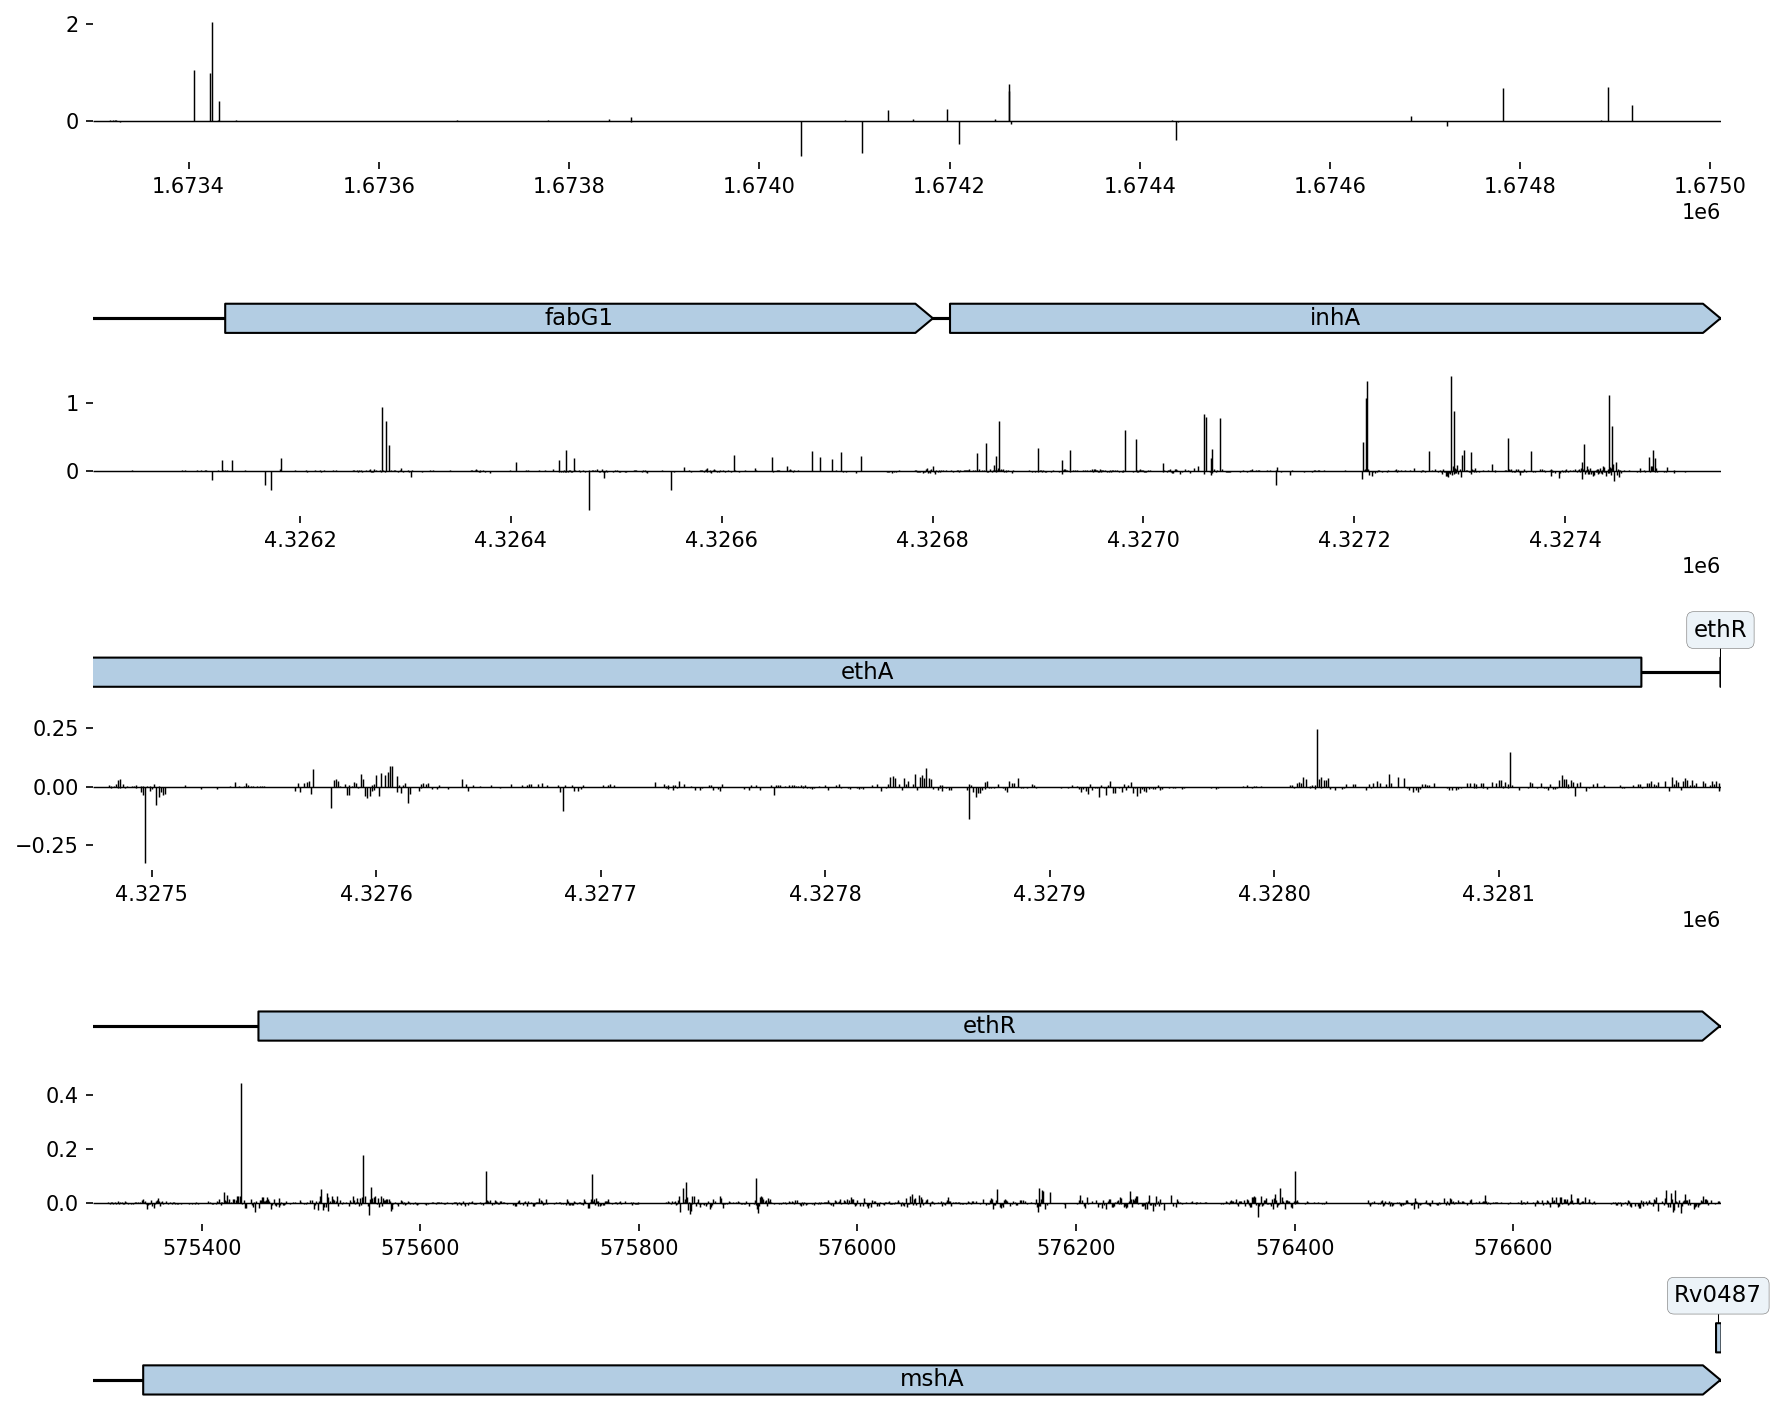

In [19]:
drug = 'ETO'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_amino_acid")

ETO_df, ETO_seqDict = generate_saliency_plots(drug,
                                      model_path,
                                      kwargs['tier1_loci'],
                                      fasta_dir=kwargs['genotype_input_directory'],
                                      cat_to_check=["1"],
                                      save=False,
                                      significance=True,
                                      sig_thresh=0.05,
                                     )

# ETO_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

## Correlate ethA SSM with Saliency scores

In [220]:
df_ethA_SSM = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/inSilico_analysis/saturation_mutagenesis/ethA/test_predictions.csv")

ETO_H37Rv_pred = df_ethA_SSM.query("ROLLINGDB_ID == 'MT_H37Rv'").pred_MIC.values[0]

df_ethA_SSM = df_ethA_SSM.query("ROLLINGDB_ID != 'MT_H37Rv' &~ROLLINGDB_ID.str.contains('\*')")

ethA_start, ethA_end, ethA_sense = h37Rv_genes.query("Symbol=='ethA'")[['Start', 'End', 'Strand']].values[0]

df_ethA_SSM['Codon'] = df_ethA_SSM['ROLLINGDB_ID'].apply(get_variant_number, args=(ethA_sense))

# no nonsense mutations
assert len(df_ethA_SSM) == df_ethA_SSM['Codon'].max() * 19

df_ethA_SSM['ref_pred'] = ETO_H37Rv_pred

df_ethA_SSM['fold_change'] = df_ethA_SSM['pred_MIC'] / df_ethA_SSM['ref_pred']

df_ethA_FC_by_codon = pd.DataFrame(df_ethA_SSM.groupby('Codon')['fold_change'].mean()).reset_index()

In [221]:
ethA_saliency = ETO_df.query("Gene == 'ethA'")

ethA_saliency['Pos_String'] = ethA_saliency['Pos'].astype(str)
ethA_saliency = ethA_saliency.query("~Pos_String.str.contains('_')")
ethA_saliency['Pos'] = ethA_saliency['Pos'].astype(int)

del ethA_saliency['Pos_String']

if ethA_sense == '+':
    last_pos_before_stop_codon = ethA_end - 3
    ethA_saliency = ethA_saliency.query("Pos >= @ethA_start & Pos <= @last_pos_before_stop_codon").reset_index(drop=True)

elif ethA_sense == '-':
    last_pos_before_stop_codon = ethA_start + 3
    ethA_saliency = ethA_saliency.query("Pos >= @last_pos_before_stop_codon & Pos <= @ethA_end").reset_index(drop=True)

assert len(ethA_saliency) / 3 == len(df_ethA_FC_by_codon)

In [222]:
if ethA_sense == '+':
    ethA_saliency['Pos_from_Start_Codon'] = ethA_saliency['Pos'] - ethA_start
elif ethA_sense == '-':
    ethA_saliency['Pos_from_Start_Codon'] = ethA_end - ethA_saliency['Pos']

# add 1 at the end because they are 0-indexed codons at first
ethA_saliency['Codon'] = np.floor((ethA_saliency['Pos_from_Start_Codon']) / 3).astype(int) + 1

In [250]:
for i, row in ethA_saliency.iterrows():
    if row['Max_Sig'] == 0:
        ethA_saliency.loc[i, 'Max'] = np.nan
    elif row['Min_Sig'] == 0:
        ethA_saliency.loc[i, 'Min'] = np.nan

In [266]:
ethA_saliency_by_codon = ethA_saliency.groupby('Codon')[['Max', 'Min']].mean().reset_index()

assert len(ethA_saliency_by_codon.dropna(subset=['Max', 'Min'], how='all')) == len(ethA_saliency_by_codon)

df_ethA_FC_saliency_by_codon = df_ethA_FC_by_codon.merge(ethA_saliency_by_codon)

In [267]:
df_ethA_FC_saliency_by_codon

,Codon,fold_change,Max,Min
0,1,2.228127,0.035811,-0.007518
1,2,0.996674,NaN,-0.007477
2,3,0.947388,NaN,-0.004852
3,4,0.941865,NaN,-0.000154
4,5,0.989795,0.018346,-0.004470
...,...,...,...,...
484,485,1.000125,NaN,-0.000053
485,486,0.999924,NaN,-0.000010
486,487,1.000060,NaN,0.000000
487,488,1.000111,NaN,0.000000


In [261]:
codons_significant_pos_saliency = ethA_saliency.query("Max_Sig==1 & Max > 0.01").Codon.unique()
len(codons_significant_pos_saliency)

164

In [264]:
df_ethA_FC_saliency_by_codon['Significant_Max_Saliency'] = df_ethA_FC_saliency_by_codon['Codon'].isin(codons_significant_pos_saliency).astype(int)

In [243]:
df_ethA_FC_saliency_by_codon.Significant_Max_Saliency.value_counts()

Significant_Max_Saliency
0    325
1    164
Name: count, dtype: int64

In [ ]:
Sites in codons with a significant positive saliency score greater than 0.01 have significantly higher average predicted fold change for missense mutations (p << 0.01, Mann-Whitney U test) than other sites. There are 164 such codons, with an average predicted fold change of 1.32, while the average predicted fold change for the other 325 codons is 1.10.

In [269]:
# st.ttest_ind(np.log2(df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==1").fold_change),
#              np.log2(df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==0").fold_change),
#              alternative='greater'
#             )

In [245]:
st.mannwhitneyu(df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==1").fold_change,
             df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==0").fold_change,
             alternative='greater'
            )

MannwhitneyuResult(statistic=39230.0, pvalue=7.514570477917996e-18)

In [246]:
df_ethA_FC_saliency_by_codon.groupby("Significant_Max_Saliency")['fold_change'].mean()

Significant_Max_Saliency
0    1.098383
1    1.323193
Name: fold_change, dtype: float64

In [167]:
# for i, row in df_ethA_FC_saliency_by_codon.iterrows():

#     if row['Max'] >= abs(row['Min']):
#         df_ethA_FC_saliency_by_codon.loc[i, 'saliency_score'] = row['Max']
#     else:
#         df_ethA_FC_saliency_by_codon.loc[i, 'saliency_score'] = row['Min']

In [271]:
df_ethA_FC_saliency_by_codon['Mean'] = df_ethA_FC_saliency_by_codon[['Max', 'Min']].mean(axis=1)

In [272]:
df_ethA_FC_saliency_by_codon

,Codon,fold_change,Max,Min,Mean
0,1,2.228127,0.035811,-0.007518,0.014147
1,2,0.996674,NaN,-0.007477,-0.007477
2,3,0.947388,NaN,-0.004852,-0.004852
3,4,0.941865,NaN,-0.000154,-0.000154
4,5,0.989795,0.018346,-0.004470,0.006938
...,...,...,...,...,...
484,485,1.000125,NaN,-0.000053,-0.000053
485,486,0.999924,NaN,-0.000010,-0.000010
486,487,1.000060,NaN,0.000000,0.000000
487,488,1.000111,NaN,0.000000,0.000000


In [238]:
# sns.scatterplot(data=df_ethA_FC_saliency_by_codon,
#                 x='fold_change',
#                 y='Max'
#                )

# plt.xscale('log', base=2)

In [273]:
st.pearsonr(np.log2(df_ethA_FC_saliency_by_codon['fold_change']), df_ethA_FC_saliency_by_codon['Mean'])

PearsonRResult(statistic=0.5213837184322269, pvalue=1.9522499755177256e-35)

In [275]:
st.spearmanr(df_ethA_FC_saliency_by_codon['fold_change'], df_ethA_FC_saliency_by_codon['Mean'])

SignificanceResult(statistic=0.3382439795836607, pvalue=1.4906778768627607e-14)

In [190]:
df_ethA_FC_saliency_by_codon.query("fold_change > 4")

,Codon,fold_change,Max,Min,Mean
87,88,6.134557,0.809968,-0.001274,0.404347
291,292,8.771518,0.002598,-0.005305,-0.001353
302,303,5.929211,0.002296,-0.001271,0.000512
478,479,4.843933,0.000652,-0.000004,0.000324


In [206]:
# df_ethA_SSM.query("Codon in [303, 479]")#.drop_duplicates('Codon')

In [5]:
ETO_df.query("Gene=='mshA' & Max_Sig==1").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
136,mshA,575436.0,0.443382,0.0,1.0,0.0
249,mshA,575548.0,0.178330,0.0,1.0,0.0
1362,mshA,mshA_26,0.158977,0.0,1.0,0.0
1516,mshA,mshA_34,0.154236,0.0,1.0,0.0
364,mshA,575660.0,0.116794,0.0,1.0,0.0
...,...,...,...,...,...,...
1517,mshA,576783.0,0.000356,0.0,1.0,0.0
3,mshA,575304.0,0.000090,0.0,1.0,0.0
1,mshA,575302.0,0.000059,0.0,1.0,0.0
0,mshA,575301.0,0.000045,0.0,1.0,0.0


In [6]:
pos = 575436
locus = 'mshA'

locus_idx = kwargs['tier1_loci'].index(locus)
ref = ETO_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: C


({'A': 0.0, 'C': 0.0, 'T': 0.4433818, 'G': 0.0, '-': 0.012596381},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0})

In [7]:
get_isolates_with_variant_of_interest(pos, locus, ETO_seqDict, 'T', df_ETO, 'ETO')

1 isolates with position 575436 = T


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMEA1101745,575436,C,T,PASS,3010.0,False,1.0,93.0,33.0,...,mshA,c.89C>T,p.Pro30Leu,mshA_p.Pro30Leu,Ethionamide,3) Uncertain significance,10.0,inf,train_set,3
1,SAMEA1101745,657081,C,T,PASS,983.0,False,1.0,29.0,34.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,10.0,inf,train_set,3
2,SAMEA1101745,1673425,C,T,PASS,3084.0,False,1.0,89.0,35.0,...,Rv1482c-fabG1,n.1673425C>T,NaN,inhA_c.-777C>T,Ethionamide,1) Assoc w R,10.0,inf,train_set,3


In [67]:
df_ETO_tier2_insilico_pred = pd.read_csv("./results/Ethionamide/insilico_pred_tier2.csv")

In [73]:
addl_high_MIC = df_ETO_tier2_insilico_pred.query("gene in ['ndh', 'mshA', 'Rv3083', 'Rv0565c'] & fold_change > 2")
len(addl_high_MIC)

20

In [74]:
addl_high_MIC.gene.value_counts()

gene
Rv0565c    9
mshA       7
Rv3083     3
ndh        1
Name: count, dtype: int64

In [76]:
addl_high_MIC.effect.value_counts()

effect
stop_gained          16
inframe_deletion      2
missense_variant      1
inframe_insertion     1
Name: count, dtype: int64

In [77]:
addl_high_MIC[['gene', 'effect']].value_counts()

gene     effect           
mshA     stop_gained          7
Rv0565c  stop_gained          6
Rv3083   stop_gained          2
Rv0565c  inframe_deletion     1
         inframe_insertion    1
         missense_variant     1
Rv3083   inframe_deletion     1
ndh      stop_gained          1
Name: count, dtype: int64

In [78]:
addl_high_MIC.query("effect=='missense_variant'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
182,Rv0565c_p.Gly189Arg,1.539074,2.906078,missense_variant,5,Rv0565c,3) Uncertain significance,1.071134,2.713086,1.439935,Rv0565c,Ethionamide


In [82]:
addl_high_MIC.sort_values(['gene', 'pred_MIC'], ascending=[True, False]).to_csv("./results/Ethionamide/new_genes_greater_doubling.csv", index=False)

In [4]:
drug = 'ETO'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_tier2_amino_acid")

ETO_tier2_df, ETO_tier2_seqDict = generate_saliency_plots(drug,
                                              model_path,
                                              kwargs['tier1_loci'] + kwargs['tier2_loci'],
                                              fasta_dir=kwargs['genotype_input_directory'],
                                              cat_to_check=["1"],
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

ETO_tier2_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

7 loci!
Plotting significant saliency scores for fabG1-inhA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethR using 10 max scores and 10 min scores
Plotting significant saliency scores for mshA using 10 max scores and 10 min scores
Plotting significant saliency scores for Rv0565c using 10 max scores and 10 min scores
Plotting significant saliency scores for ndh using 10 max scores and 10 min scores
Plotting significant saliency scores for Rv3083 using 10 max scores and 10 min scores


In [27]:
def get_NT_with_max_score(locus, pos, saliency_df, scores_array):

    locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
    idx = saliency_df.query("Pos==@pos").index.values[0] 

    max_scores = np.max(scores_array[:, :, idx, locus_idx], axis=0)
    # min_scores = np.min(scores_array[:, :, idx, locus_idx], axis=0)
    
    base_with_max_score = list(BASE_TO_COLUMN.keys())[max_scores.argmax()]
    # base_with_min_score = list(BASE_TO_COLUMN.keys())[min_scores.argmin()]

    return np.max(max_scores), base_with_max_score#, base_with_min_score

In [30]:
df_ndh_NTs_with_max_score = pd.DataFrame(columns = ['Pos', 'Max', 'NT'])
i = 0

for pos in ETO_tier2_df.query("Gene=='ndh'").Pos.values:
    max_score, NT_max_score = get_NT_with_max_score('ndh', pos, ETO_tier2_df, ETO_tier2_scores)
    df_ndh_NTs_with_max_score.loc[i, :]  = [pos, max_score, NT_max_score]
    i += 1

In [99]:
df_mshA_NTs_with_max_score = pd.DataFrame(columns = ['Pos', 'Max', 'NT'])
i = 0

for pos in ETO_tier2_df.query("Gene=='mshA'").Pos.values:
    max_score, NT_max_score = get_NT_with_max_score('mshA', pos, ETO_tier2_df, ETO_tier2_scores)
    df_mshA_NTs_with_max_score.loc[i, :]  = [pos, max_score, NT_max_score]
    i += 1

In [101]:
df_mshA_NTs_with_max_score.query("Max > 0").sort_values("Max", ascending=False)

,Pos,Max,NT
136,575436.0,0.368093,T
1515,mshA_33,0.16675,G
1516,mshA_34,0.107823,C
615,575907.0,0.070897,T
132,575432.0,0.067233,-
...,...,...,...
25,575326.0,0.00003,-
0,575301.0,0.000024,-
1523,576789.0,0.000017,-
2,575303.0,0.000009,-


In [110]:
who_variants.query("variant=='ethA_p.Asn287_Leu333del'")[['Present_SOLO_S', 'Present_SOLO_R', 'Present_S', 'Present_R']]

,Present_SOLO_S,Present_SOLO_R,Present_S,Present_R
16519,8.0,1.0,8.0,4.0


In [107]:
get_isolates_with_variant_of_interest(575907, 'mshA', ETO_tier2_seqDict, 'T', df_ETO, 'ETO')

2778 isolates with position 575907 = T


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMN13813839,575907,C,T,PASS,3914.0,False,1.00,115.0,34.0,...,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,0.375,0.75,train_set,2
1,SAMN13813839,657081,C,T,PASS,3511.0,False,1.00,103.0,34.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,0.375,0.75,train_set,2
2,SAMN13813839,657142,C,T,PASS,2794.0,False,1.00,87.0,32.0,...,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,0.375,0.75,train_set,2
3,SAMN13813884,575907,C,T,PASS,7059.0,False,1.00,208.0,34.0,...,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,12.500,25.00,train_set,2
4,SAMN13813884,657081,C,T,PASS,6927.0,False,1.00,201.0,34.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,12.500,25.00,train_set,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10661,SAMEA7562299,575913,C,CCG,PASS,2027.0,NaN,0.77,57.0,36.0,...,mshA,NaN,NaN,mshA_LoF,Ethionamide,3) Uncertain significance,1.250,2.50,train_set,2
10662,SAMEA7562299,575920,C,CG,PASS,2020.0,False,1.00,56.0,36.0,...,mshA,c.574dupG,p.Asp192fs,mshA_p.Asp192fs,Ethionamide,3) Uncertain significance,1.250,2.50,train_set,2
10663,SAMEA7562299,657081,C,T,PASS,1556.0,False,1.00,43.0,36.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,1.250,2.50,train_set,2
10664,SAMEA7562299,657142,C,T,PASS,1650.0,False,1.00,47.0,35.0,...,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,1.250,2.50,train_set,2


In [96]:
df_ndh_NTs_with_max_score.query("Max > 0").sort_values("Max", ascending=False)

,Pos,Max,NT
84,2103099.0,0.066078,G
118,2103065.0,0.009014,A
1131,ndh_20,0.004266,G
87,2103096.0,0.002082,T
275,2102910.0,0.001988,T
751,ndh_12,0.001632,G
452,ndh_2,0.000723,G
779,2102417.0,0.000033,T


In [95]:
get_isolates_with_variant_of_interest('ndh_20', locus, ETO_tier2_seqDict, 'G', df_ETO, 'ETO')

3 isolates with position ndh_20 = G


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMEA3401667,575907,C,T,PASS,2415.0,False,1.00,72.0,34.0,...,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,3.0,4.0,test_set,2
1,SAMEA3401667,657081,C,T,PASS,2150.0,False,1.00,66.0,33.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,3.0,4.0,test_set,2
2,SAMEA3401667,657142,C,T,PASS,3058.0,False,1.00,84.0,36.0,...,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,3.0,4.0,test_set,2
3,SAMEA3401667,2102072,G,GCC,PASS,3704.0,False,1.00,101.0,37.0,...,ndh,c.969_970dupGG,p.Ala324fs,ndh_p.Ala324fs,Ethionamide,3) Uncertain significance,3.0,4.0,test_set,2
4,SAMEA3401667,2102072,G,GCC,PASS,3704.0,NaN,1.00,101.0,37.0,...,ndh,NaN,NaN,ndh_LoF,Ethionamide,3) Uncertain significance,3.0,4.0,test_set,2
5,SAMEA3401667,4326570,A,C,PASS,3744.0,False,1.00,105.0,36.0,...,ethA,c.904T>G,p.Phe302Val,ethA_p.Phe302Val,Ethionamide,3) Uncertain significance,3.0,4.0,test_set,2
6,SAMN02398700,575907,C,T,PASS,2439.0,False,1.00,75.0,33.0,...,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,5.0,10.0,validation_set,2
7,SAMN02398700,657081,C,T,PASS,3976.0,False,0.98,124.0,35.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,5.0,10.0,validation_set,2
8,SAMN02398700,657142,C,T,PASS,3446.0,False,0.98,102.0,37.0,...,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,5.0,10.0,validation_set,2
9,SAMN02398700,2102072,G,GC,PASS,2856.0,NaN,0.97,79.0,36.0,...,ndh,NaN,NaN,ndh_LoF,Ethionamide,3) Uncertain significance,5.0,10.0,validation_set,2


In [52]:
samples_with_ndh_LoF = isolate_variants.query("GENE=='ndh' & EFFECT in ['frameshift_variant', 'stop_gained']").merge(df_ETO[['ROLLINGDB_ID', 'category', 'Binary']]).ROLLINGDB_ID.unique()

len(samples_with_ndh_LoF)

30

In [83]:
positions_with_fs = isolate_variants.query("GENE=='ndh' & EFFECT in ['frameshift_variant', 'stop_gained']").merge(df_ETO[['ROLLINGDB_ID', 'category', 'Binary']]).drop_duplicates(['ROLLINGDB_ID', 'variant'])[['ROLLINGDB_ID', 'POS', 'REF', 'ALT', 'variant']][['POS', 'REF', 'ALT']].POS.unique()

isolate_variants.query("GENE=='ndh' & EFFECT in ['frameshift_variant', 'stop_gained']").merge(df_ETO[['ROLLINGDB_ID', 'category', 'Binary']]).drop_duplicates(['ROLLINGDB_ID', 'variant'])[['ROLLINGDB_ID', 'POS', 'REF', 'ALT', 'variant']][['POS', 'REF', 'ALT']].value_counts()

POS      REF  ALT   
2102709  AG   A         6
2102038  G    GC        6
2102728  A    ACC       6
2102050  A    AC        4
2102070  C    CG        4
2102072  G    GCC       4
2102140  G    GC        4
2102034  T    TG        4
2102024  GC   G         2
2103027  CT   C         2
2103021  T    TG        2
2102733  G    GC        2
2102179  G    GTC       2
2102638  T    TGCGAA    2
2102409  T    TC        2
2102408  A    ATC       2
2102072  G    GC        2
2102050  AC   A         2
2103032  TG   T         2
Name: count, dtype: int64

In [74]:
ETO_tier2_seqDict['ndh'].loc[samples_with_ndh_LoF][2102039]

Isolate
SAMEA3401667    G
SAMN02398700    G
SAMN02398701    G
SAMN02398702    G
SAMN05916337    G
SAMN05918764    G
SAMN06010374    G
SAMN06094096    G
SAMEA1101698    G
SAMEA1101757    G
SAMEA5570007    G
SAMEA7525255    G
SAMEA7525296    G
SAMEA7525357    G
SAMEA7525473    G
SAMEA7525614    G
SAMEA7525644    G
SAMEA7526075    G
SAMEA7555802    G
SAMEA7562423    G
SAMEA7563188    G
SAMEA8741432    G
SAMEA8741442    G
SAMEA8741456    G
SAMEA8741466    G
SAMEA8741519    G
SAMEA8741579    G
SAMEA8741615    G
SAMEA8741511    G
SAMN12787860    G
Name: 2102039.0, dtype: object

In [20]:
ETO_tier2_df.query("Gene=='mshA'").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
615,mshA,575907.0,0.200084,0.000000,1.0,0.0
129,mshA,575429.0,0.151075,0.000000,1.0,0.0
132,mshA,575432.0,0.132834,0.000000,1.0,0.0
763,mshA,576051.0,0.130493,0.000000,1.0,0.0
131,mshA,575431.0,0.127136,0.000000,1.0,0.0
...,...,...,...,...,...,...
662,mshA,575950.0,0.000000,-0.000553,0.0,0.0
663,mshA,575951.0,0.000000,-0.008900,0.0,1.0
664,mshA,575952.0,0.000000,-0.001690,0.0,0.0
666,mshA,575954.0,0.000000,-0.009339,0.0,1.0


In [43]:
pos = 576051
locus = 'mshA'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: T


({'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.13049279},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0})

In [44]:
get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, '-', df_ETO, 'ETO')

2 isolates with position 576051 = -


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,...,mshA,NaN,NaN,mshA_LoF,Ethionamide,3) Uncertain significance,10.0,inf,train_set,3
1,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,False,NaN,NaN,NaN,...,Rv0484c&Rv0485&Rv0487&mshA,n.577427_573527del,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,10.0,inf,train_set,3
2,SAMEA1101660,657081,C,T,PASS,1494.0,False,1.0,41.0,36.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,10.0,inf,train_set,3
3,SAMEA3392627,574011,TCACTCAGCCGCAAGCCCGGCCGCAAGCACCAGCTGCGATCGCACC...,T,PASS,0.0,NaN,NaN,NaN,NaN,...,mshA,NaN,NaN,mshA_LoF,Ethionamide,3) Uncertain significance,14.0,inf,train_set,4


In [45]:
ETO_tier2_df.query("Gene=='Rv0565c'").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
1037,Rv0565c,656522.0,0.226810,0.000000,1.0,0.0
1478,Rv0565c,656100.0,0.029485,0.000000,1.0,0.0
1004,Rv0565c,656555.0,0.025627,0.000000,1.0,0.0
1318,Rv0565c,Rv0565c_21,0.022235,0.000000,1.0,0.0
119,Rv0565c,657428.0,0.022151,0.000000,1.0,0.0
...,...,...,...,...,...,...
521,Rv0565c,Rv0565c_6,0.000000,-0.000231,0.0,0.0
520,Rv0565c,Rv0565c_5,0.000000,0.000000,0.0,0.0
519,Rv0565c,657033.0,0.000000,0.000000,0.0,0.0
518,Rv0565c,657034.0,0.000000,0.000000,0.0,0.0


In [61]:
pos = 656522
locus = 'Rv0565c'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: G


({'A': 0.0, 'C': 0.22680964, 'T': 0.0, 'G': 0.0, '-': 0.0},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0})

In [62]:
get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, 'C', df_ETO, 'ETO')

2 isolates with position 656522 = C


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMN05918601,575907,C,T,PASS,2800.0,False,1.0,73.0,38.0,...,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,1.25,2.5,train_set,2
1,SAMN05918601,656522,C,G,PASS,2800.0,False,1.0,72.0,39.0,...,Rv0565c,c.949G>C,p.Val317Leu,Rv0565c_p.Val317Leu,Ethionamide,3) Uncertain significance,1.25,2.5,train_set,2
2,SAMN05918601,657081,C,T,PASS,2704.0,False,1.0,69.0,39.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,1.25,2.5,train_set,2
3,SAMN05918601,657142,C,T,PASS,2869.0,False,1.0,73.0,39.0,...,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,1.25,2.5,train_set,2
4,SAMEA5569641,575907,C,T,PASS,5026.0,False,1.0,129.0,39.0,...,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,5.00,10.0,train_set,2
5,SAMEA5569641,656522,C,G,PASS,4705.0,False,1.0,119.0,40.0,...,Rv0565c,c.949G>C,p.Val317Leu,Rv0565c_p.Val317Leu,Ethionamide,3) Uncertain significance,5.00,10.0,train_set,2
6,SAMEA5569641,657081,C,T,PASS,5195.0,False,1.0,135.0,39.0,...,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,5.00,10.0,train_set,2
7,SAMEA5569641,657142,C,T,PASS,5555.0,False,1.0,143.0,39.0,...,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,5.00,10.0,train_set,2
8,SAMEA5569641,1673425,C,T,PASS,3290.0,False,1.0,85.0,39.0,...,Rv1482c-fabG1,n.1673425C>T,NaN,inhA_c.-777C>T,Ethionamide,1) Assoc w R,5.00,10.0,train_set,2


In [65]:
isolate_variants.query("variant=='ndh_p.Ala324fs'").drop_duplicates('ROLLINGDB_ID').merge(df_ETO)

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
0,SAMEA3401667,2102072,G,GCC,PASS,3704.0,False,1.00,101.0,37.0,...,beijing,lin2.2.1,NaN,0.007184,2,-7.120908,0,0.0,2-0,test_set
1,SAMN02398700,2102072,G,GC,PASS,2856.0,False,0.97,79.0,36.0,...,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.018764,2,-5.735920,0,1.0,2-1,validation_set
2,SAMEA7526075,2102072,G,GCC,PASS,2059.0,False,0.97,69.0,30.0,...,"east_african_indian,ghana,mungi",NaN,NaN,0.018986,3,-5.718924,0,1.0,3-1,train_set


In [53]:
ETO_tier2_df.query("Gene=='ndh'").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
909,ndh,2102290.0,0.008424,0.0,1.0,0.0
751,ndh,ndh_12,0.006367,0.0,1.0,0.0
156,ndh,2103028.0,0.006100,0.0,1.0,0.0
1134,ndh,ndh_21,0.003224,0.0,1.0,0.0
1022,ndh,2102179.0,0.002434,0.0,1.0,0.0
...,...,...,...,...,...,...
516,ndh,2102672.0,0.000000,0.0,0.0,0.0
515,ndh,2102673.0,0.000000,0.0,0.0,0.0
514,ndh,2102674.0,0.000000,0.0,0.0,0.0
513,ndh,2102675.0,0.000000,0.0,0.0,0.0


In [59]:
pos = 2103028
locus = 'ndh'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: A


({'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.006099931},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0})

In [60]:
get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, '-', df_ETO, 'ETO')

1 isolates with position 2103028 = -


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMEA1101698,576077,C,T,PASS,3291.0,False,1.0,91.0,36.0,...,mshA,c.730C>T,p.Leu244Leu,mshA_c.730C>T,Ethionamide,4) Not assoc w R - Interim,1.25,2.5,train_set,4
1,SAMEA1101698,657425,C,T,PASS,1007.0,False,1.0,28.0,36.0,...,Rv0565c,c.46G>A,p.Gly16Ser,Rv0565c_p.Gly16Ser,Ethionamide,3) Uncertain significance,1.25,2.5,train_set,4
2,SAMEA1101698,2103027,CT,C,PASS,0.0,False,1.0,48.0,0.0,...,ndh,c.15delA,p.Glu6fs,ndh_p.Glu6fs,Ethionamide,3) Uncertain significance,1.25,2.5,train_set,4
3,SAMEA1101698,2103027,CT,C,PASS,0.0,NaN,1.0,48.0,0.0,...,ndh,NaN,NaN,ndh_LoF,Ethionamide,3) Uncertain significance,1.25,2.5,train_set,4


In [17]:
ETO_tier2_df.query("Gene=='Rv3083'").sort_values("Max", ascending=False).head(10)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
122,Rv3083,3448545.0,0.068905,0.000000,1.0,0.0
125,Rv3083,3448548.0,0.058714,-0.003722,1.0,1.0
153,Rv3083,3448575.0,0.057875,-0.000498,1.0,1.0
133,Rv3083,3448555.0,0.054358,-0.013535,1.0,1.0
881,Rv3083,3449295.0,0.054317,-0.000015,1.0,0.0
123,Rv3083,3448546.0,0.053157,0.000000,1.0,0.0
139,Rv3083,3448561.0,0.052704,-0.008982,1.0,1.0
141,Rv3083,3448563.0,0.052423,-0.005620,1.0,1.0
802,Rv3083,3449216.0,0.049266,-0.002826,1.0,1.0
1477,Rv3083,3449885.0,0.046879,0.000000,1.0,0.0


In [48]:
pos = 3448548
locus = 'Rv3083'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: C


({'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0587139},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': -0.0037224588})

In [51]:
Rv3083_deletions = get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, '-', df_ETO, 'ETO').query("GENE==@locus")

473 isolates with position 3448548 = -


In [58]:
Rv3083_deletions#[['ROLLINGDB_ID', 'POS', 'REF', 'ALT']]

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
2,SAMEA104362109,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,1.250,2.50,test_set,4
3,SAMEA104362138,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,1.250,2.50,train_set,4
6,SAMEA104362219,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,1.250,2.50,test_set,4
9,SAMEA104362247,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,0.625,1.25,train_set,4
10,SAMEA104362264,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,1.250,2.50,train_set,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156,SAMN38209960,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,1.250,2.50,train_set,4
1157,SAMN38210009,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,1.250,2.50,test_set,4
1159,SAMN38210035,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,PASS,0.0,NaN,NaN,NaN,NaN,...,Rv3083,NaN,NaN,Rv3083_LoF,Ethionamide,3) Uncertain significance,0.000,1.25,train_set,4
1160,SAMN38210035,3449108,G,A,Del;Amb;LowCov,80.0,False,0.5,2.0,40.0,...,Rv3083,c.605G>A,p.Gly202Asp,Rv3083_p.Gly202Asp,Ethionamide,3) Uncertain significance,0.000,1.25,train_set,4


In [64]:
Rv3083_deletions['Deletion_Length'] = Rv3083_deletions['REF'].str.len() - Rv3083_deletions['ALT'].str.len()

In [69]:
Rv3083_deletions.query("variant=='Rv3083_LoF'")[['POS', 'REF', 'ALT', 'Deletion_Length']].drop_duplicates().sort_values("POS")

,POS,REF,ALT,Deletion_Length
846,3440706,TGGACGTAGACGTGGTGGCCGCGGCCCTGGCCGAATCGTTCTCCGA...,TTTCGGCGATCGCGTCGCGATGACCCCGGACCCTTCGTGGCCGCCC...,13032
1075,3442716,TACCGGCGCCAGTTCGTTTCGCGCATCGGATTCCCGTCCGGTGGCG...,TGATCACCACCTTGCTGCCGCTGGCGCGGCCAAGCTCGGCGCGGTA...,13363
291,3443151,CCTGGCGGCCAGGTAGTCCACTGCACCCCCCTCGGAACCCAGCAGA...,C,8947
206,3445673,GGTAGGGCATCACGATGAAGGGCCGCCCACCCGCCAACACGCCCAC...,G,5997
1056,3446188,ATCTGTGGACGGTGGAACGCGCGGCGCGCCATTGGGGCGTGAGCGC...,A,4255
1012,3448443,ATGATAAAAGGCTGTCGCAAAGTGTCAATACGTGGCGGGGGTCCTC...,A,481
364,3448455,TGTCGCAAAGTGTCAATACGTGGCGGGGGTCCTCCACCATGCTGGA...,T,8409
270,3448462,AAGTGTCAATACGTGGCGGGGGTCCTCCACCATGCTGGAGCCATGA...,AGTGTCAATACGTGGCGGGGGTCCTCCACCATGCAGGGTCCATGA,2892
2,3448496,CTGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGG...,CAGGGTCCATGA,2891
822,3448497,TGGAGCCATGAACCAGCATTTCGACGTCCTGATCATCGGCGCCGGC...,AGGGTCCATGA,2891


In [80]:
Rv3083_deletions.query("variant=='Rv3083_LoF'")['EFFECT'].unique()

array(['start_lost', 'frameshift_variant', 'transcript_ablation'],
      dtype=object)

In [76]:
Rv3083_deletions.query("variant=='Rv3083_LoF'").merge(df_ETO[['ETO_lower_bound', 'ETO_midpoint', 'Binary', 'ETO_upper_bound', 'ROLLINGDB_ID']]).ETO_midpoint.mean()#.ROLLINGDB_ID.nunique()

3.220322410147992

In [77]:
Rv3083_deletions.query("variant=='Rv3083_LoF'").merge(df_ETO[['ETO_lower_bound', 'ETO_midpoint', 'Binary', 'ETO_upper_bound', 'ROLLINGDB_ID']]).Binary.value_counts()

Binary
0.0    380
1.0     89
Name: count, dtype: int64

In [26]:
isolate_variants.query("ROLLINGDB_ID in @search_isolates & drug=='Ethionamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
475391,SAMEA7560779,656444,C,T,PASS,3556.0,False,1.00,107.0,34.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.1027G>A,p.Val343Ile,Rv0565c_p.Val343Ile,Ethionamide,3) Uncertain significance
475438,SAMEA7560779,3448714,G,C,PASS,2383.0,False,1.00,74.0,32.0,60.0,0.0,0.0,missense_variant,Rv3083,c.211G>C,p.Asp71His,Rv3083_p.Asp71His,Ethionamide,3) Uncertain significance
479712,SAMEA7560852,656444,C,A,PASS,1379.0,False,0.98,47.0,33.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.1027G>T,p.Val343Phe,Rv0565c_p.Val343Phe,Ethionamide,3) Uncertain significance
479771,SAMEA7560852,3448714,G,C,PASS,1481.0,False,1.00,44.0,34.0,60.0,0.0,0.0,missense_variant,Rv3083,c.211G>C,p.Asp71His,Rv3083_p.Asp71His,Ethionamide,3) Uncertain significance
484889,SAMEA7560966,656444,C,G,PASS,1732.0,False,0.94,67.0,34.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.1027G>C,p.Val343Leu,Rv0565c_p.Val343Leu,Ethionamide,3) Uncertain significance
484890,SAMEA7560966,657081,C,T,PASS,2154.0,False,0.99,67.0,33.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim
561395,SAMEA7562891,656444,C,A,PASS,2883.0,False,1.00,74.0,39.0,59.0,0.0,0.0,missense_variant,Rv0565c,c.1027G>T,p.Val343Phe,Rv0565c_p.Val343Phe,Ethionamide,3) Uncertain significance
561442,SAMEA7562891,3448472,A,T,PASS,2635.0,False,0.97,74.0,40.0,60.0,0.0,0.0,intergenic_region,virS-Rv3083,n.3448472A>T,NaN,Rv3083_c.-32A>T,Ethionamide,3) Uncertain significance
561444,SAMEA7562891,3448714,G,C,PASS,2458.0,False,0.96,79.0,38.0,60.0,0.0,0.0,missense_variant,Rv3083,c.211G>C,p.Asp71His,Rv3083_p.Asp71His,Ethionamide,3) Uncertain significance


In [42]:
pos = 657428
locus = 'Rv0565c'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETH_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETH_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: G


({'A': 0.0, 'C': 0.0, 'T': 0.22138439, 'G': 0.0, '-': 0.0},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0})

In [43]:
isolate_variants.query("POS==@pos")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
675590,657428,C,A,PASS,4967.0,False,0.83,387.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.43G>T,p.Val15Phe,Rv0565c_p.Val15Phe,Ethionamide,3) Uncertain significance,SAMEA8741644


In [47]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA8741644' & drug=='Ethionamide'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
675583,575907,C,T,PASS,7923.0,False,1.00,207.0,38.0,60.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,SAMEA8741644
675588,657081,C,T,PASS,12109.0,False,1.00,318.0,38.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,SAMEA8741644
675589,657142,C,T,PASS,15783.0,False,1.00,408.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,SAMEA8741644
675590,657428,C,A,PASS,4967.0,False,0.83,387.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.43G>T,p.Val15Phe,Rv0565c_p.Val15Phe,Ethionamide,3) Uncertain significance,SAMEA8741644
675610,1673432,T,C,PASS,12892.0,False,1.00,334.0,39.0,60.0,0.0,0.0,intergenic_region,Rv1482c-fabG1,n.1673432T>C,NaN,inhA_c.-770T>C,Ethionamide,2) Assoc w R - Interim,SAMEA8741644
675635,4326087,GT,G,PASS,0.0,False,1.00,273.0,40.0,60.0,0.0,272.0,frameshift_variant,ethA,c.1386delA,p.Arg463fs,ethA_p.Arg463fs,Ethionamide,2) Assoc w R - Interim,SAMEA8741644


In [44]:
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

In [46]:
df_ETO_phenos.query("ROLLINGDB_ID=='SAMEA8741644'")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
8266,SAMEA8741644,7H10,5.0,7.5,10.0,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.00694,2.2.1,2.2.1.1.1,"beijing,canetti,mungi","europe/russia_B0/W148_outbreak,lin2.2.1",NaN,2,0,1.0,2-1,train_set


# Pyrazinamide

4 loci!
Plotting significant saliency scores for pncA using 10 max scores and 10 min scores
Plotting significant saliency scores for panD using 10 max scores and 10 min scores
Plotting significant saliency scores for rpsA using 10 max scores and 10 min scores
Plotting significant saliency scores for clpC1 using 10 max scores and 10 min scores


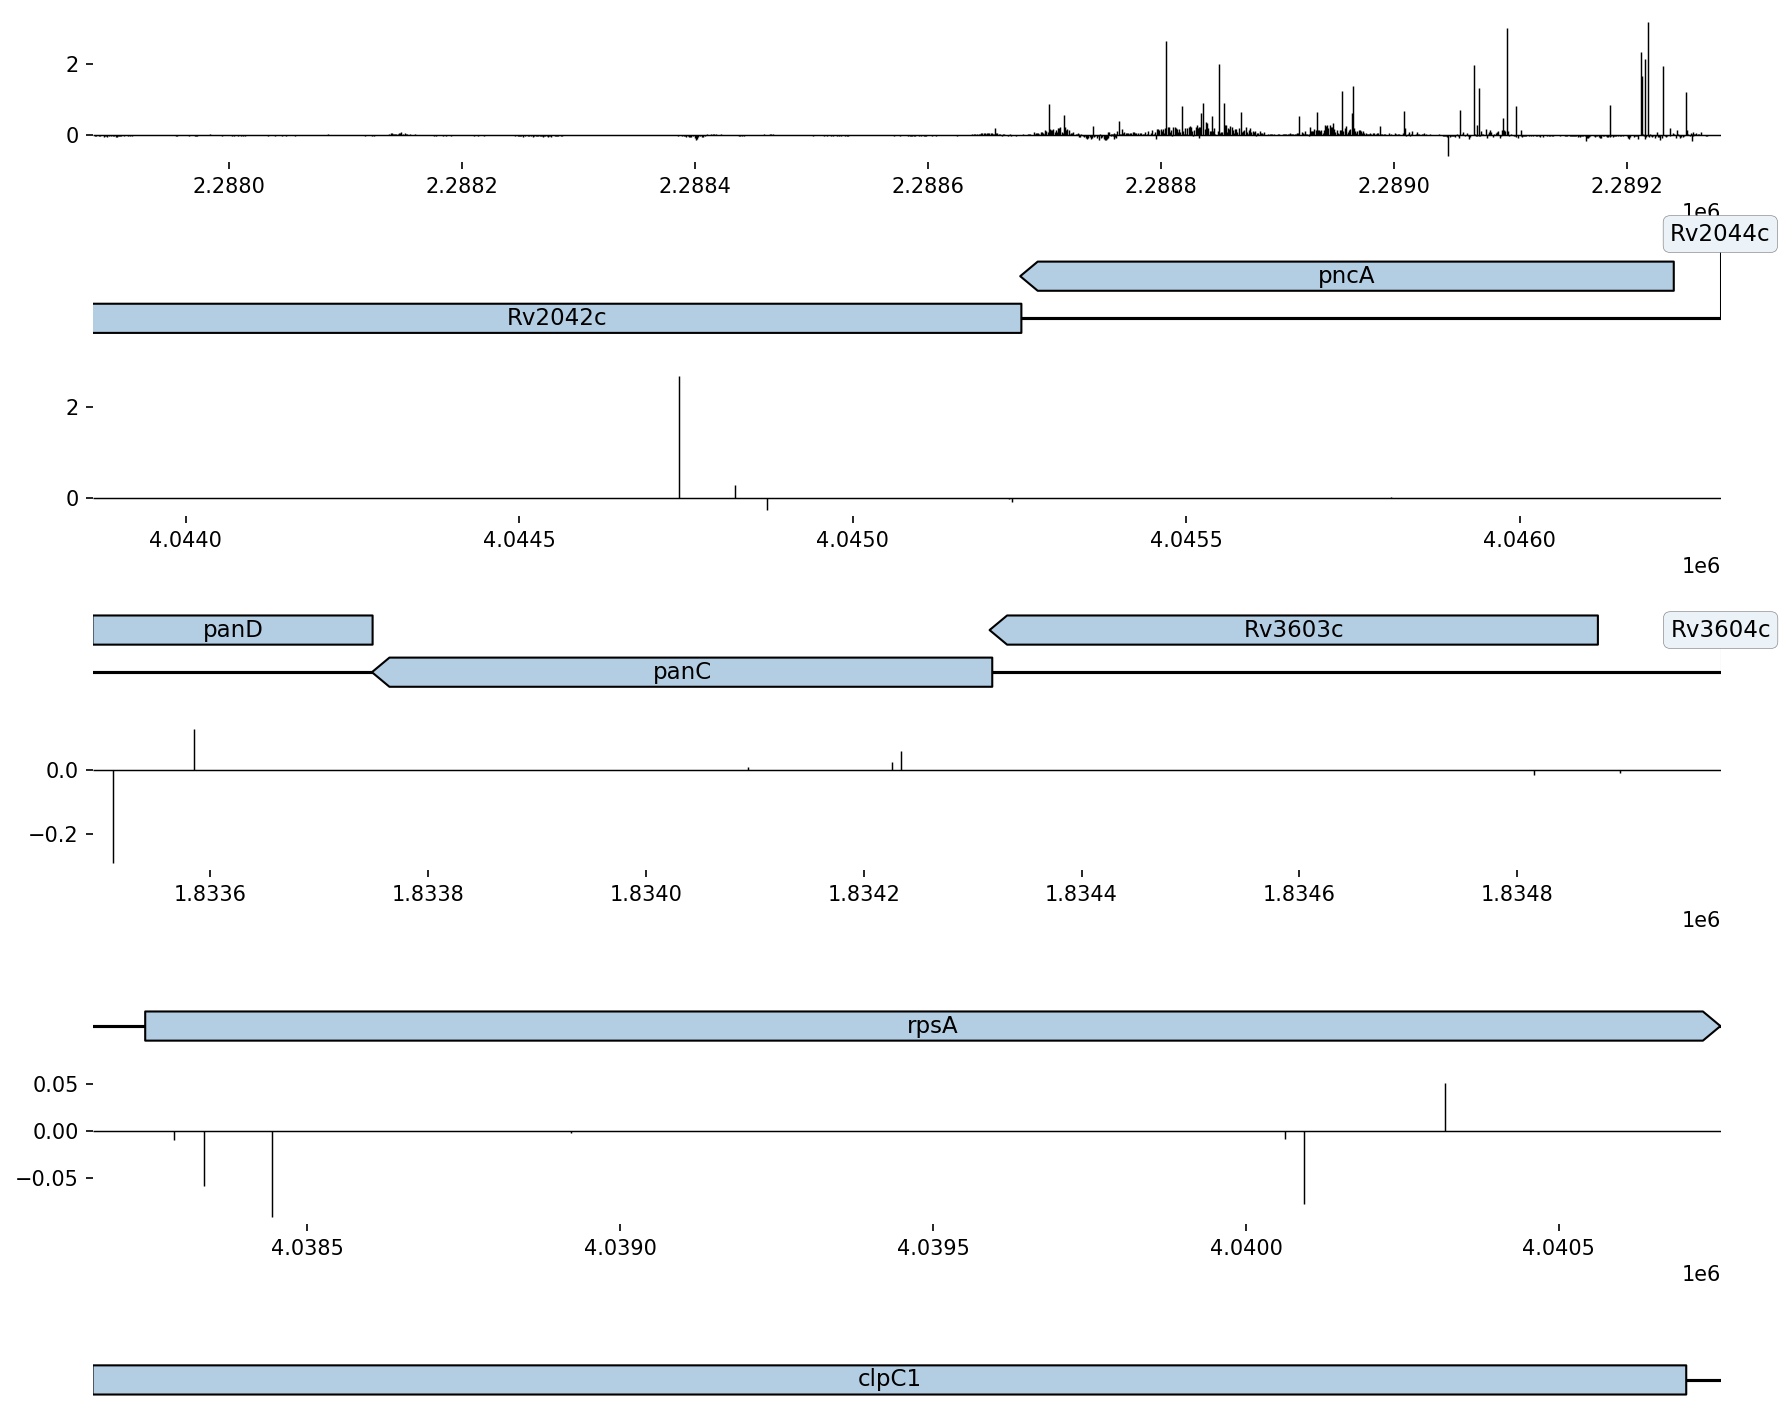

In [26]:
drug = 'PZA'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_amino_acid")

PZA_df, PZA_seqDict = generate_saliency_plots(drug,
                                              model_path,
                                              kwargs['tier1_loci'],
                                              fasta_dir=kwargs['genotype_input_directory'],
                                              cat_to_check=["1"],
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

PZA_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [4]:
model_loci.query("Locus=='clpC1'")

,Locus,Start,End,Sense
24,clpC1,4038157,4040759,-


# Lineage Saliency Plots

In [68]:
def generate_lineage_saliency_plot(drug, model_path, lineage_mat=lineages_matrix, annot_thresh=0.25, significance=True, savefName=None):
    
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv")).query("category=='train_set'")
    df_phenos["log2_MIC"] = np.log2(df_phenos[f"{drug}_midpoint"])
    mean_log_mic = np.mean(df_phenos["log2_MIC"])
    
    
    ################################### STEP 1: MAKE A DATAFRAME OF THE LINEAGE SNPS (AND PEPTIDE LENGTHS, IF SO) WITH SCORES ###################################


    if "_peptide" in model_path:
        genes_lst = pd.read_csv(os.path.join(results_dir, drug, "gene_peptide_lengths.csv"), index_col=[0]).columns
        genes_lst = [gene.replace("_length", "") for gene in genes_lst]
    else:
        genes_lst = []
        
    # get only the training or testing set and subset the lineage matrix too
    lineage_mat = lineage_mat.loc[df_phenos["ROLLINGDB_ID"]]
    
    saliency_dir = os.path.join(results_dir, model_path, "saliency")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "mlp_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": list(genes_lst) + list(lineage_mat.columns), 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0),
                                      # 'Mean': lineage_scores.mean(axis=0), # take the average activation of each lineage SNP across the training isolates
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["Lineage", "position"]], on="position")
    

    ################################### STEP 2: COMPUTE AVERAGE MIC OF EACH LINEAGE DIVIDED BY AVERAGE OF THE WHOLE DATASET ###################################


    lineage_scores_df['Mean_log2_MIC'] = mean_log_mic
    
    # add log2-MIC to get averaged per lineage later
    lineage_mat = lineage_mat.merge(df_phenos[["ROLLINGDB_ID", "log2_MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    # get the prediction for H37Rv from the in silico analysis directory
    df_insilico = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis", "lineage_SNP_predictions.csv"))
    H37Rv_pred = df_insilico.query("Lineage=='MT_H37Rv'")['log2_pred_MIC'].values[0]
    
    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineage_mat.loc[lineage_mat[row["position"]]==1]["log2_MIC"].mean()
        lineage_scores_df.loc[i, ["log2_MIC", "MIC"]] = [log2_MIC, np.exp2(log2_MIC)]
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = row["position"], row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        # keep track of the number of training isolates of each lineae
        lineage_scores_df.loc[i, 'Num_Isolates'] = len(isolates_in_lineage)

        # hypothesis test to compare mean of isolates in a particular lineage to the entire dataset
        if len(isolates_in_lineage) > 0:

            if log2_MIC > mean_log_mic:
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug}_midpoint"].values, 
                                               df_phenos[f"{drug}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_pval"] = np.nan

        
    ################################### STEP 3: GET P-VALUES FOR USING PERMUTATION MODEL SCORES ###################################

    
    # get permutation score results
    if significance:

        lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/mlp_scores*.npy"))
        assert len(lineage_scores_paths) == 10

        lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

        lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values

        # get p-values from the permutation test
        for i, row in lineage_scores_df.iterrows():

            # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
            if row["Max"] > 0:
                lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > row["Max"])
            else:
                lineage_scores_df.loc[i, "Max_pval"] = np.nan

            if row["Min"] < 0:
                lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < row["Min"])
            else:
                lineage_scores_df.loc[i, "Min_pval"] = np.nan

        lineage_scores_df["Bonferroni_MIC_pval"] = lineage_scores_df["MIC_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_pval"])])
        
        # assert len(lineage_scores_df.query("MIC_pval > BH_MIC_pval")) == 0
        assert len(lineage_scores_df.query("MIC_pval > Bonferroni_MIC_pval")) == 0

        # smallest possible non-zero p-value is 0.1, so get p-values smaller than that
        significant_lineages = lineage_scores_df.query("(Max_pval < 0.1 & Max > 0) | (Min_pval < 0.1 & Min < 0)").reset_index(drop=True)
        
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have significant saliency scores")

    else:
        significant_lineages = lineage_scores_df.query("Max > 0 | Min < 0")

        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have non-zero saliency scores")
    
    freq_thresh = 2
    significant_lineages = significant_lineages.query("Num_Isolates >= @freq_thresh")
    print(f"{len(significant_lineages)} lineages have at least {freq_thresh} isolates")
    
        
    ################################### STEP 4: CREATE AN AGGREGATE SALIENCY SCORE FOR EACH LINEAGE ###################################
    

    # the threshold for significance is 0.1 because the only possible p-values are 0, 0.1, 0.2, 0.3....1 because there were 10 permuted models
    pval_thresh = 0.1
    
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():
        
        if significance:

            
            if row["Max_pval"] < pval_thresh:

                # if Max is significant, but not Min
                if pd.isnull(row["Min_pval"]) or row["Min_pval"] >= pval_thresh:
                    significant_lineages.loc[i, "plot_score"] = row["Max"]

                else:
                    # take the one with the absolute value if both are significant because it's likely that the one with the larger absolute magnitude 
                    # is more prevalent in the dataset and affects the average MIC more
                    # print(f"L{row['Lineage']} has both positive and negative significant saliency scores: {row['Max']}, {row['Min']}")
                    if row['Max'] >= np.abs(row['Min']):
                        significant_lineages.loc[i, "plot_score"] = row['Max']
                    else:
                        significant_lineages.loc[i, "plot_score"] = row['Min']

            # if Max is not significant, but Min is
            elif row["Min_pval"] < pval_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Min"]

            # there's no else because we already filtered to keep lineages that are significant in at least Max or Min
            else:
                continue
                
        else:
            if row["Max"] > np.abs(row["Min"]):
                significant_lineages.loc[i, "plot_score"] = row["Max"]
            else:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
            
    
    ################################### STEP 5: FIT A LINEAR REGRESSION TO PLOT A LINE OF BEST FIT ###################################


    # fit a linear regression
    xvar = 'plot_score'
    yvar = "log2_MIC"
    fig, ax = plt.subplots(figsize=(4, 4))
        
    X = significant_lineages[xvar].values.reshape(-1, 1)
    y = significant_lineages[yvar]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)

    H37Rv_line_pred = np.squeeze(linReg.predict(np.array([0]).reshape(-1, 1)))
    
    # print(f"Line of best fit prediction for H37Rv: {np.round(np.exp2(H37Rv_line_pred), 3)}")
    print(f"In silico CNN prediction for H37Rv: {np.round(np.exp2(H37Rv_pred), 3)}")
    
    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, zorder=1, label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")
    
    # plot lineages that have significant Max and Min scores
    sns.scatterplot(data=significant_lineages, x=xvar, y=yvar, ax=ax, s=25, linewidth=0.5, alpha=0.75, edgecolor="black", zorder=2)

    right_adj = 0.03
    up_adj = 0.1
    
    label_thresh = 0
    
    for i, row in significant_lineages.iterrows():

        if np.abs(row['plot_score']) >= annot_thresh:
            
            # if drug == "MXF":
            #     if row["Lineage"] == "4.4.1.2":
            #         ax.text(row["plot_score"] - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     elif row["Lineage"] in ['4.3.1', '4.2.2.1']:
            #         ax.text(row["plot_score"] + right_adj*2, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
            #     elif row["Lineage"] in ['4.1.1.2', '4.2.1']:
            #         ax.text(row["plot_score"] + right_adj - 0.25, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     else:
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            # elif drug == 'BDQ':
            #     if row['Lineage'] == '4.3.3':
            #         ax.text(row["plot_score"] + right_adj - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     elif row['Lineage'] == '4.2.2':
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     elif row['Lineage'] == '4.3.1':
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj*3.5, row["Lineage"], color='black', fontsize=6)
            #     elif row['Lineage'] == '3.1.2':
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj*4, row["Lineage"], color='black', fontsize=6)
            #     else:
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            # else:
            #     ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)

            ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)

    # plt.scatter(0, H37Rv_pred, marker="*", color="yellow", edgecolor="black", linewidth=0.5, s=50, zorder=3, label='H37Rv Prediction')    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
    plt.ylabel("Average MIC (µg/mL)", fontsize=8)
    
    plt.legend(fontsize=6, loc="upper left")
    plt.xlabel("Saliency Score", fontsize=8)
    sns.despine()
    
    corr_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{abbr_drug_dict[drug]} Model, Spearman R = {np.round(corr_results[0], 2)}, pval = {np.round(corr_results[1], 2)}", fontsize=10)
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, format='svg', bbox_inches='tight')
        
    return significant_lineages

BDQ
54/62 lineages have significant saliency scores
52 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.032


EMB
59/62 lineages have significant saliency scores
58 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 1.249


ETO
53/62 lineages have significant saliency scores
51 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 1.002


INH
55/62 lineages have significant saliency scores
55 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.048


LFX
52/62 lineages have significant saliency scores
50 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.253


MXF
55/62 lineages have significant saliency scores
55 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.087


PZA
No results files for PZA

RIF
56/62 lineages have significant saliency scores
55 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.059




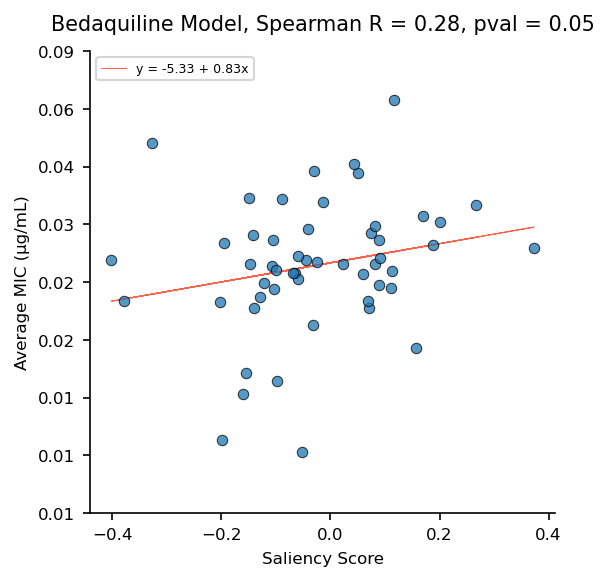

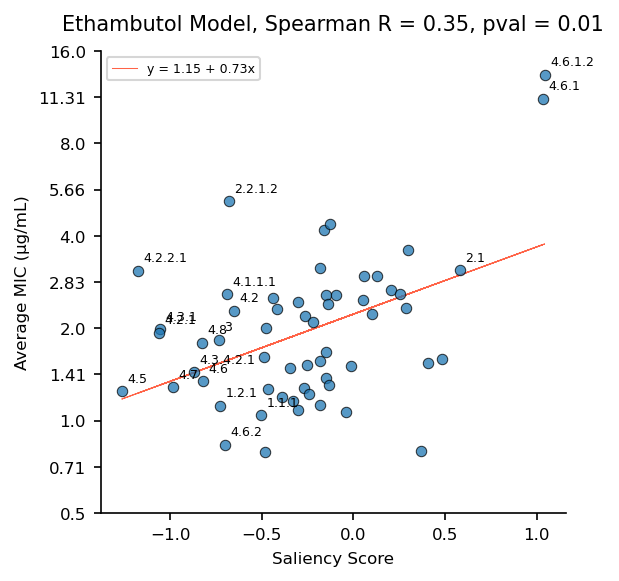

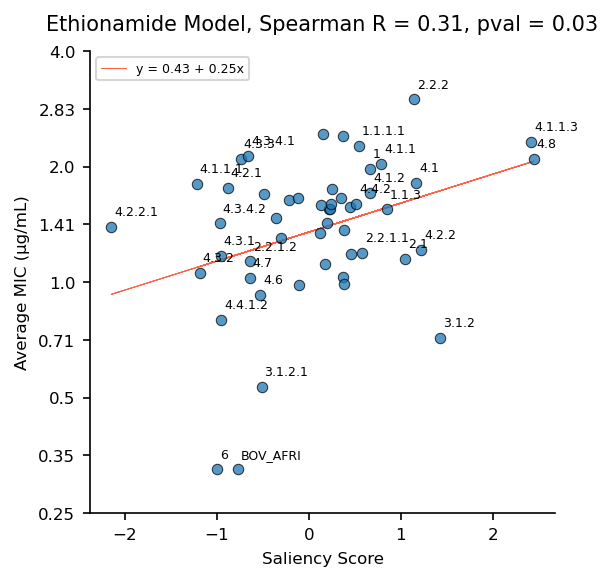

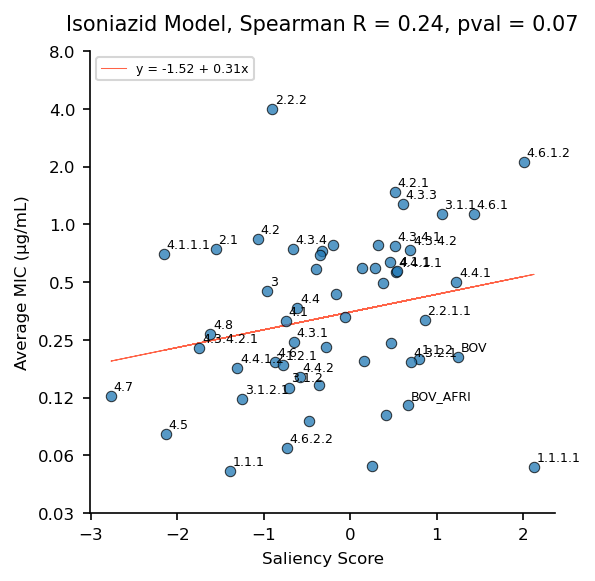

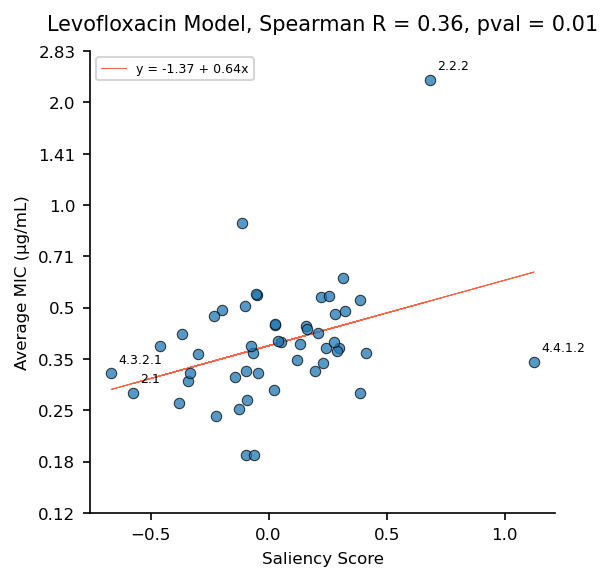

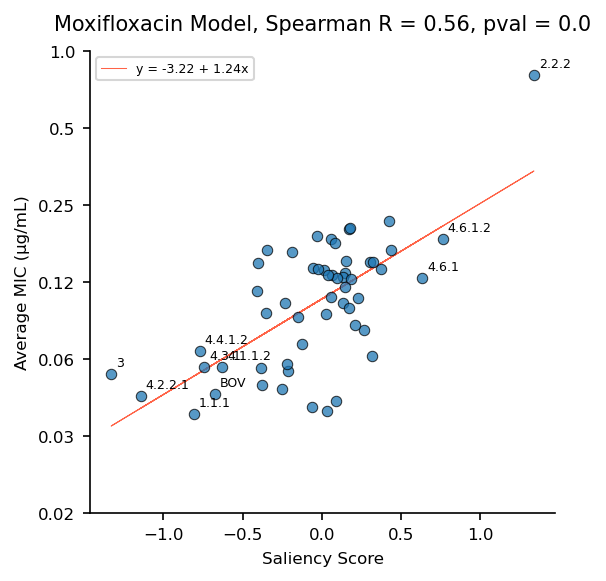

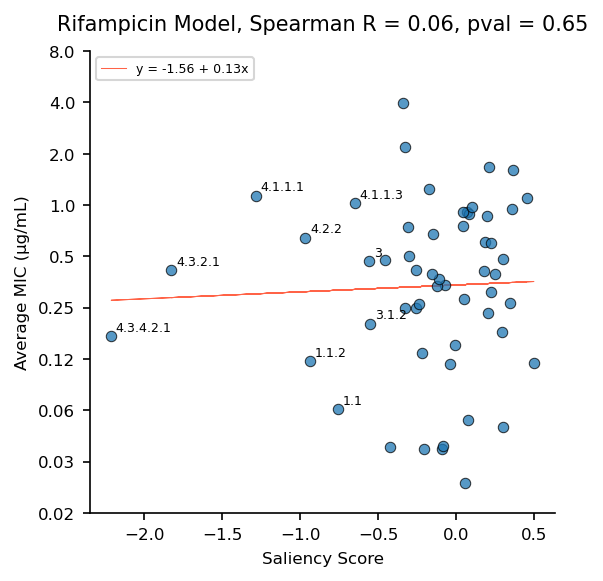

In [69]:
for drug in drugs_lst:

    try:
        print(drug)

        if drug == 'BDQ':
            model_path = f"BDQ_augment_lineage_amino_acid"
        elif drug == 'ETO':
            model_path = f"ETO_lineage_amino_acid_old"
        else:
            model_path = f"{drug}_lineage_amino_acid"
            
        _ = generate_lineage_saliency_plot(drug,
                                                                   model_path, 
                                                                   annot_thresh=0.5,
                                                                   significance=True,
                                                                   savefName=f"./results/{abbr_drug_dict[drug]}/lineage_saliency_scatter.svg"
                                                                 )
        print("\n")
    except:
        print(f"No results files for {drug}\n")

# Is MIC Significantly Elevated in Certain Lineages

In [18]:
RIF_sig_lineage_scores_df.query("Lineage in ['4.2.1', '2.2.1']")

NameError: name 'RIF_sig_lineage_scores_df' is not defined

In [ ]:
RIF_sig_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

In [ ]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [ ]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

In [ ]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [ ]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [ ]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [ ]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [ ]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [ ]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [ ]:
test.shape

In [ ]:
4819/(4819+1198)

In [ ]:
1198/(4819+1198)

In [ ]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

In [ ]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())